In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
from utils import label_mapping_utils as lmu

In [2]:
nup_genesets = {

    # Full nuclear transport — everything together
    # Use only for exploratory overview, too broad for mechanistic claims
    "nuclear_transport_all": [
        "NUP107", "NUP133", "NUP160", "NUP85", "NUP37", "NUP43", "SEH1L", "SEC13",
        "NUP155", "NUP93", "NUP188", "NUP205", "NUP35",
        "NUP62", "NUP58", "NUP54", "NUP98", "NUP88", "NUP214",
        "NUP153", "NUP50", 
    ],

    "up_in_deg": ["NUP155","NUP58","NUP160","NUP93","NUP88","NUP54","TPR","NUP37","RANBP2","NUP153","EIF4E","NUP50","RAE1","NCBP2","NCBP1","NUP98","NUP85","NUP35","NUP205","NUP62"]

}

# SlideTags

In [2]:
SLIDETAGS_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata_zoned_ct-cured_aligned.h5ad"
slidetags = sc.read_h5ad(SLIDETAGS_PATH, backed="r")

slidetags_matrix = slidetags[slidetags.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2"])].to_memory().copy()

In [ ]:
from utils import label_mapping_utils as lmu
leiden_cluster_names = lmu.preprocess_common_pipeline(slidetags_matrix, umap_name="", leiden_name="", resolutions = [0.1], integrate_with_harmony=True, batch_key="sample")


Seed set to 42


Running HVG...
HVG computed with batch_key='sample'
Subsetting to copy with only HVG...
Scaling ...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Running Harmony...
Running PCA before Harmony...


2026-06-08 16:22:33,025 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-06-08 16:22:33 | [INFO] Running Harmony (PyTorch on cuda)
2026-06-08 16:22:33,026 - harmonypy - INFO -   Parameters:
2026-06-08 16:22:33 | [INFO]   Parameters:
2026-06-08 16:22:33,027 - harmonypy - INFO -     max_iter_harmony: 30
2026-06-08 16:22:33 | [INFO]     max_iter_harmony: 30
2026-06-08 16:22:33,028 - harmonypy - INFO -     max_iter_kmeans: 20
2026-06-08 16:22:33 | [INFO]     max_iter_kmeans: 20
2026-06-08 16:22:33,029 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-06-08 16:22:33 | [INFO]     epsilon_cluster: 1e-05
2026-06-08 16:22:33,030 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-06-08 16:22:33 | [INFO]     epsilon_harmony: 0.0001
2026-06-08 16:22:33,030 - harmonypy - INFO -     nclust: 100
2026-06-08 16:22:33 | [INFO]     nclust: 100
2026-06-08 16:22:33,031 - harmonypy - INFO -     block_size: 0.05
2026-06-08 16:22:33 | [INFO]     block_size: 0.05
2026-06-08 16:22:33,032 - harm

Running Harmony batch correction...


2026-06-08 16:22:33,836 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-08 16:22:33 | [INFO] Computing initial centroids with sklearn.KMeans...
2026-06-08 16:22:34,891 - harmonypy - INFO - KMeans initialization complete.
2026-06-08 16:22:34 | [INFO] KMeans initialization complete.
2026-06-08 16:22:35,253 - harmonypy - INFO - Iteration 1 of 30
2026-06-08 16:22:35 | [INFO] Iteration 1 of 30
2026-06-08 16:22:36,074 - harmonypy - INFO - Iteration 2 of 30
2026-06-08 16:22:36 | [INFO] Iteration 2 of 30
2026-06-08 16:22:36,541 - harmonypy - INFO - Iteration 3 of 30
2026-06-08 16:22:36 | [INFO] Iteration 3 of 30
2026-06-08 16:22:37,031 - harmonypy - INFO - Iteration 4 of 30
2026-06-08 16:22:37 | [INFO] Iteration 4 of 30
2026-06-08 16:22:37,627 - harmonypy - INFO - Iteration 5 of 30
2026-06-08 16:22:37 | [INFO] Iteration 5 of 30
2026-06-08 16:22:38,102 - harmonypy - INFO - Iteration 6 of 30
2026-06-08 16:22:38 | [INFO] Iteration 6 of 30
2026-06-08 16:22:38,667 - 

Z_corr shape: (46077, 50), n_obs: 46077
Computing neighbors on Harmony-corrected PCA...
Computing UMAP...
Computing Leiden clusters...


In [7]:

for score_name, genes in nup_genesets.items():
    print(f"Calculating score: {score_name} with {len(genes)} genes.")
    lmu.aucell(slidetags_matrix, genes, score_name)

Calculating score: nuclear_transport_all with 21 genes.
Mapped 21/21 genes for nuclear_transport_all
Calculating score: up_in_deg with 20 genes.
Mapped 20/20 genes for up_in_deg


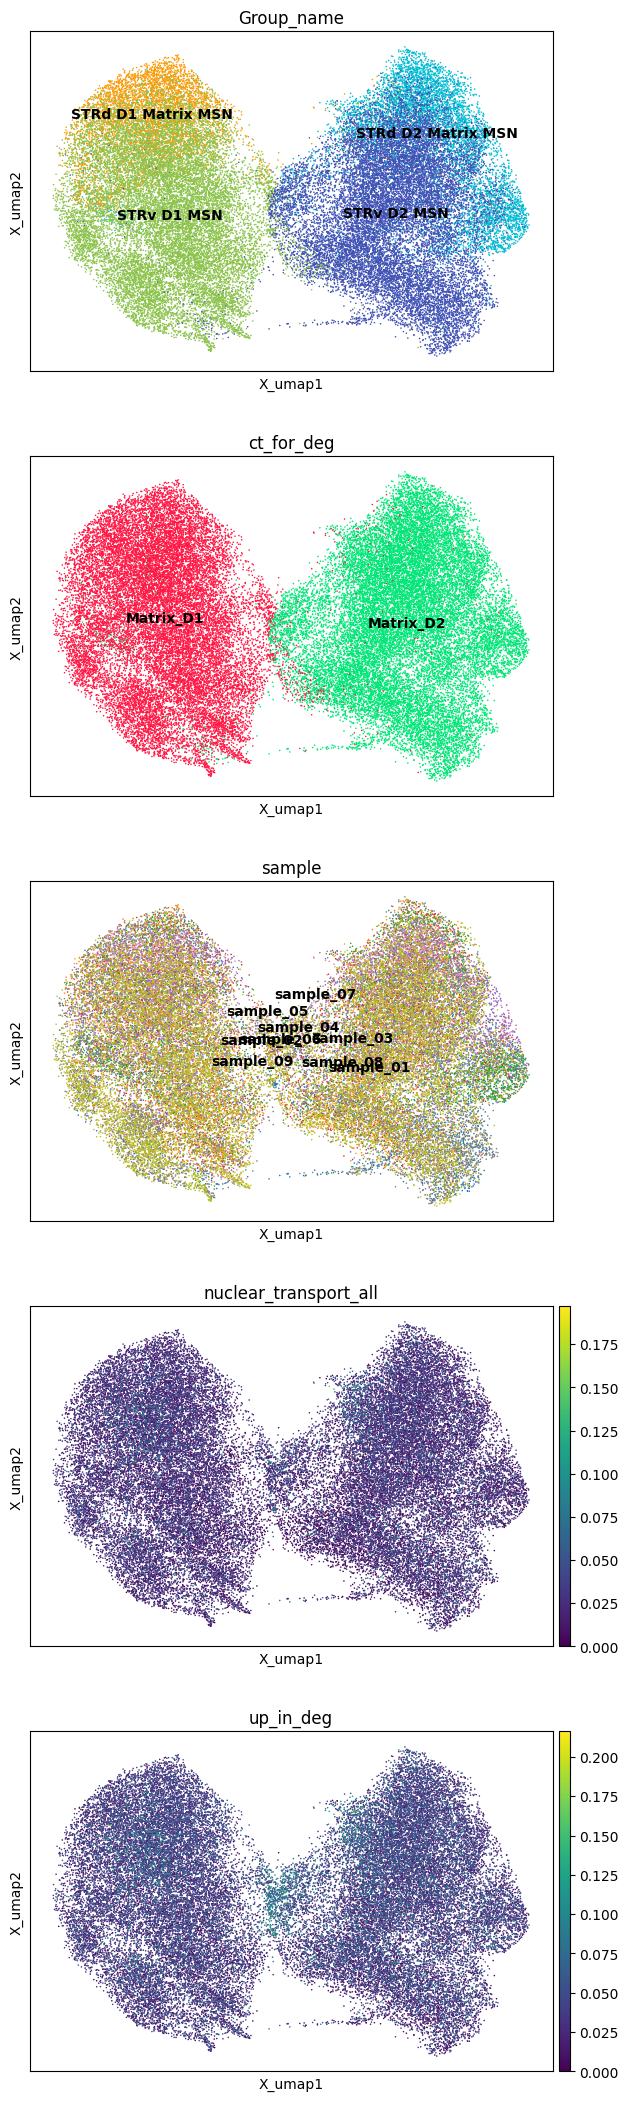

In [8]:
sc.pl.embedding(slidetags_matrix, basis="X_umap", 
                color=["Group_name", "ct_for_deg", "sample", *nup_genesets.keys()], 
                s=5, legend_loc="on data", ncols=1)

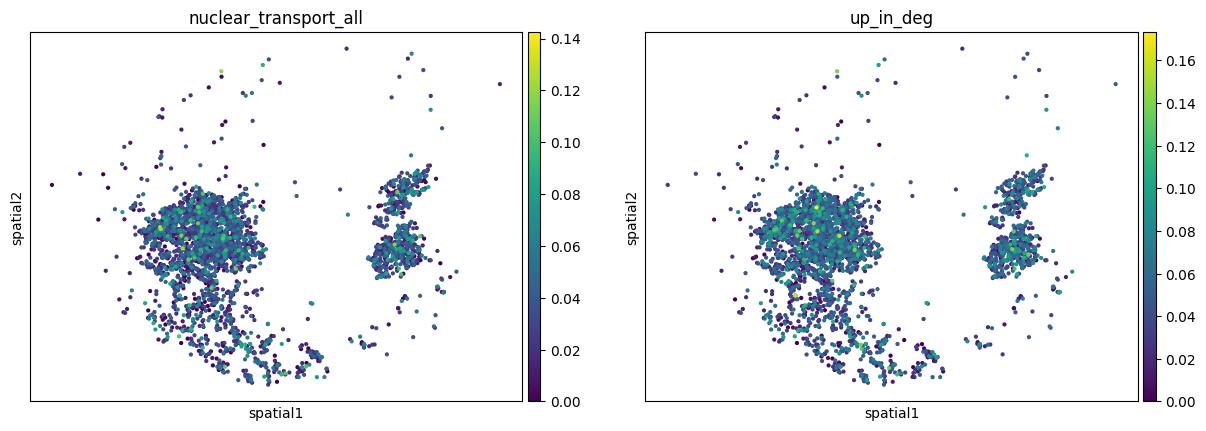

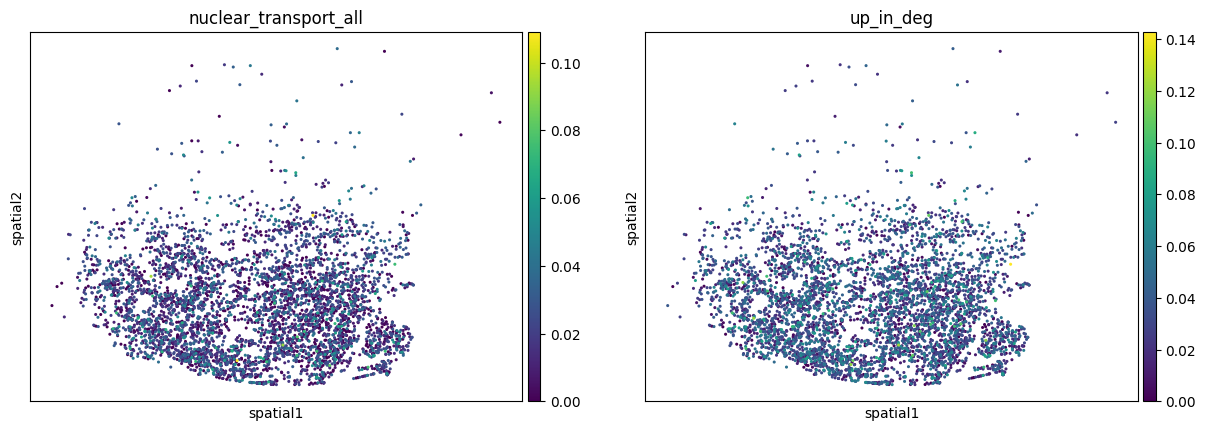

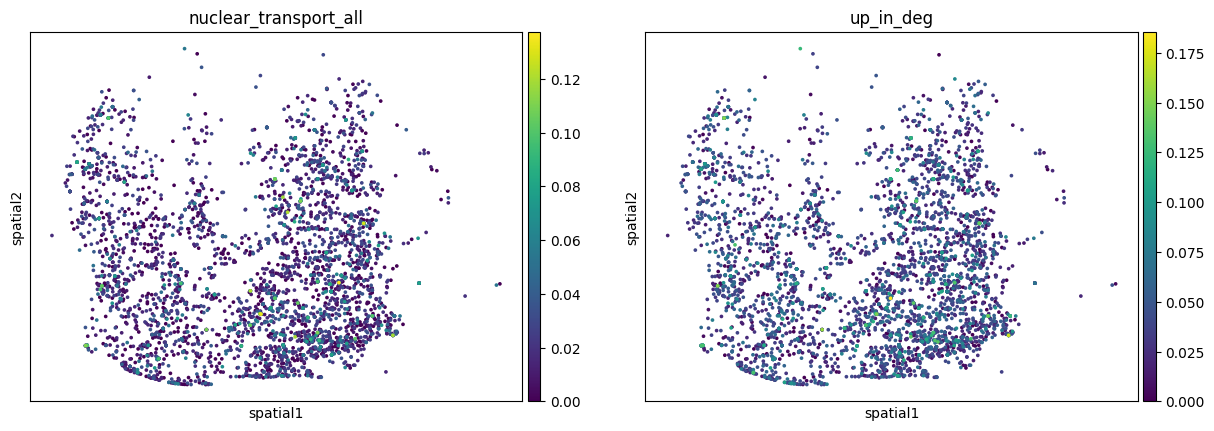

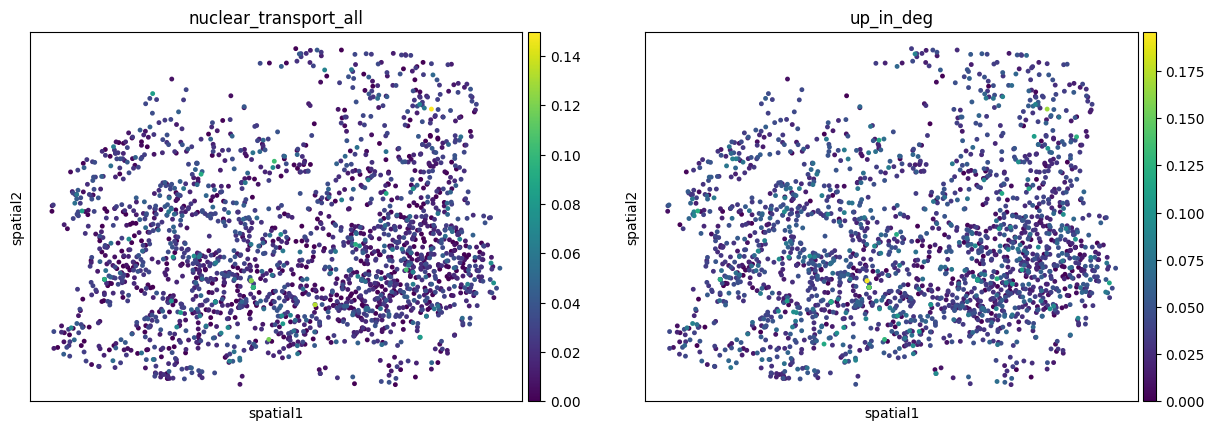

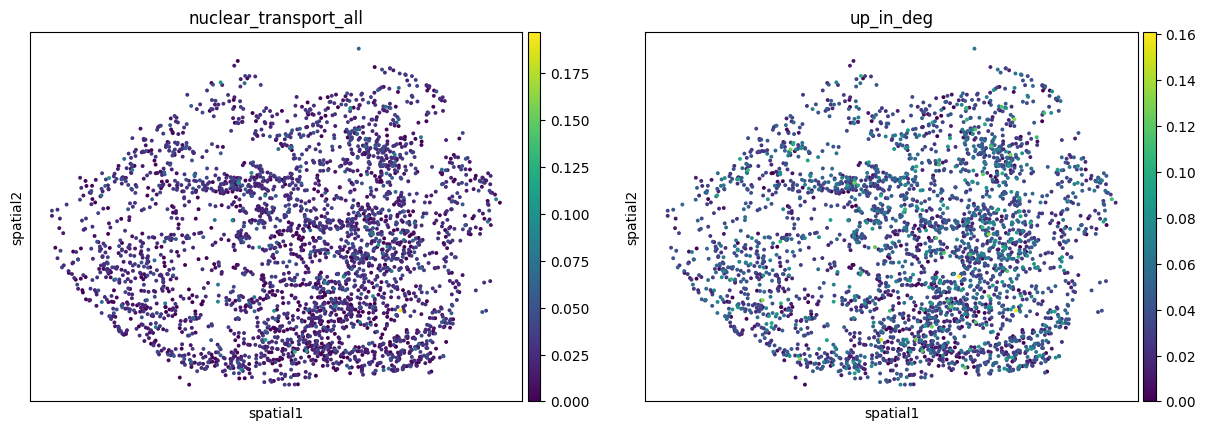

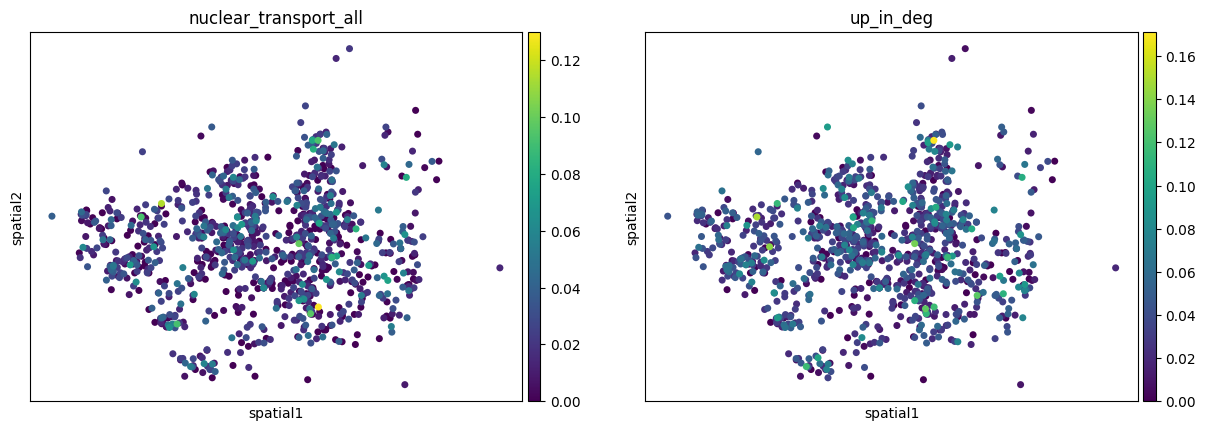

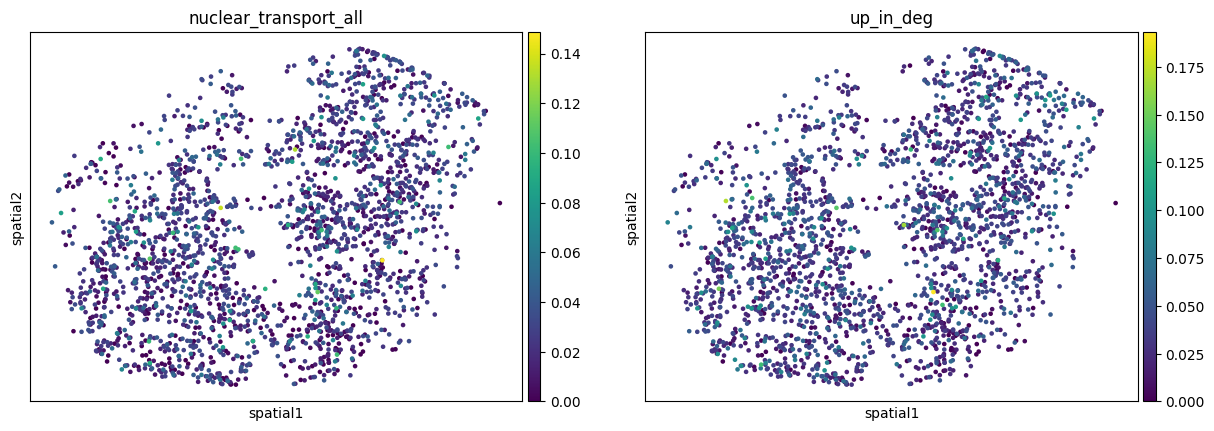

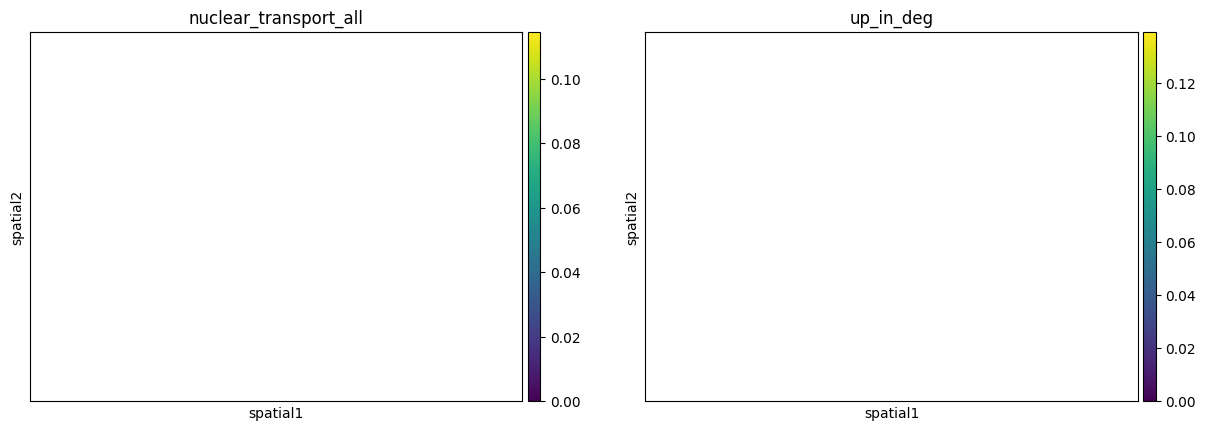

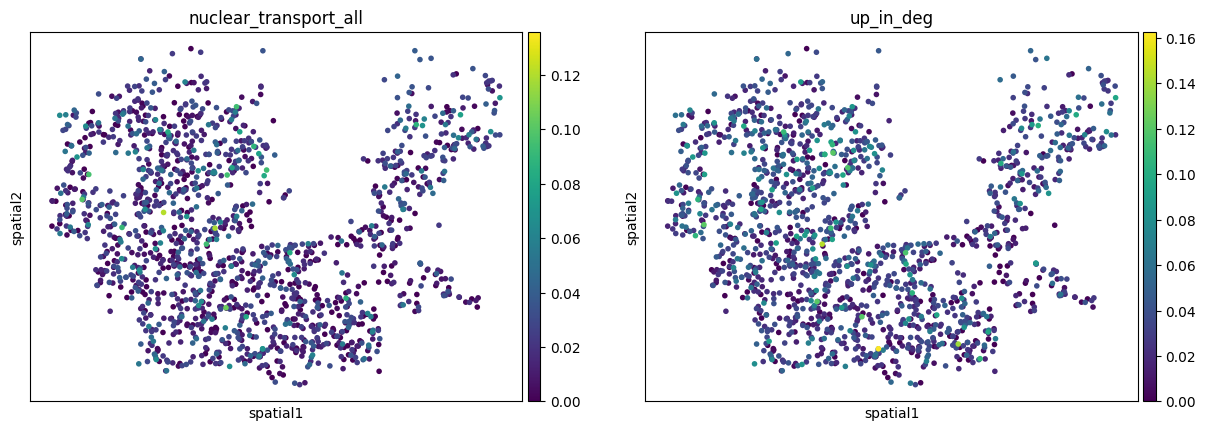

ZeroDivisionError: division by zero

In [9]:
for sample in slidetags_matrix.obs["donor_id"].unique():
    sc.pl.embedding(slidetags_matrix[slidetags_matrix.obs["donor_id"] == sample], basis='spatial', color=nup_genesets.keys(), cmap="viridis", ncols=3)
    #break

# NucSeq

With all sample levels metrics

In [3]:
NUCSEQ_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad"
nucseq = sc.read_h5ad(NUCSEQ_PATH, backed="r")

nucseq_matrix = nucseq[nucseq.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2"])].to_memory().copy()

### Compute nucelar score and plot

In [4]:
from utils import label_mapping_utils as lmu
leiden_cluster_names = lmu.preprocess_common_pipeline(nucseq_matrix, umap_name="", leiden_name="", resolutions = [0.1], integrate_with_harmony=True, batch_key="donor_id")


Seed set to 42


Running HVG...
Subsetting to copy with only HVG...
Scaling ...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Running Harmony...
Running PCA before Harmony...


2026-06-09 12:09:10,051 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-06-09 12:09:10 | [INFO] Running Harmony (PyTorch on cuda)
2026-06-09 12:09:10,053 - harmonypy - INFO -   Parameters:
2026-06-09 12:09:10 | [INFO]   Parameters:
2026-06-09 12:09:10,054 - harmonypy - INFO -     max_iter_harmony: 30
2026-06-09 12:09:10 | [INFO]     max_iter_harmony: 30
2026-06-09 12:09:10,055 - harmonypy - INFO -     max_iter_kmeans: 20
2026-06-09 12:09:10 | [INFO]     max_iter_kmeans: 20
2026-06-09 12:09:10,056 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-06-09 12:09:10 | [INFO]     epsilon_cluster: 1e-05
2026-06-09 12:09:10,057 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-06-09 12:09:10 | [INFO]     epsilon_harmony: 0.0001
2026-06-09 12:09:10,058 - harmonypy - INFO -     nclust: 100
2026-06-09 12:09:10 | [INFO]     nclust: 100
2026-06-09 12:09:10,059 - harmonypy - INFO -     block_size: 0.05
2026-06-09 12:09:10 | [INFO]     block_size: 0.05
2026-06-09 12:09:10,061 - harm

Running Harmony batch correction...


2026-06-09 12:09:10,628 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-09 12:09:10 | [INFO] Computing initial centroids with sklearn.KMeans...
2026-06-09 12:09:11,191 - harmonypy - INFO - KMeans initialization complete.
2026-06-09 12:09:11 | [INFO] KMeans initialization complete.
2026-06-09 12:09:11,318 - harmonypy - INFO - Iteration 1 of 30
2026-06-09 12:09:11 | [INFO] Iteration 1 of 30
2026-06-09 12:09:12,648 - harmonypy - INFO - Iteration 2 of 30
2026-06-09 12:09:12 | [INFO] Iteration 2 of 30
2026-06-09 12:09:14,031 - harmonypy - INFO - Iteration 3 of 30
2026-06-09 12:09:14 | [INFO] Iteration 3 of 30
2026-06-09 12:09:15,335 - harmonypy - INFO - Iteration 4 of 30
2026-06-09 12:09:15 | [INFO] Iteration 4 of 30
2026-06-09 12:09:16,390 - harmonypy - INFO - Iteration 5 of 30
2026-06-09 12:09:16 | [INFO] Iteration 5 of 30
2026-06-09 12:09:17,284 - harmonypy - INFO - Iteration 6 of 30
2026-06-09 12:09:17 | [INFO] Iteration 6 of 30
2026-06-09 12:09:18,069 - 

Z_corr shape: (22782, 50), n_obs: 22782
Computing neighbors on Harmony-corrected PCA...
Computing UMAP...
Computing Leiden clusters...


In [5]:

for score_name, genes in nup_genesets.items():
    print(f"Calculating score: {score_name} with {len(genes)} genes.")
    lmu.aucell(nucseq_matrix, genes, score_name)

Calculating score: nuclear_transport_all with 21 genes.
Mapped 21/21 genes for nuclear_transport_all
Calculating score: up_in_deg with 20 genes.
Mapped 20/20 genes for up_in_deg


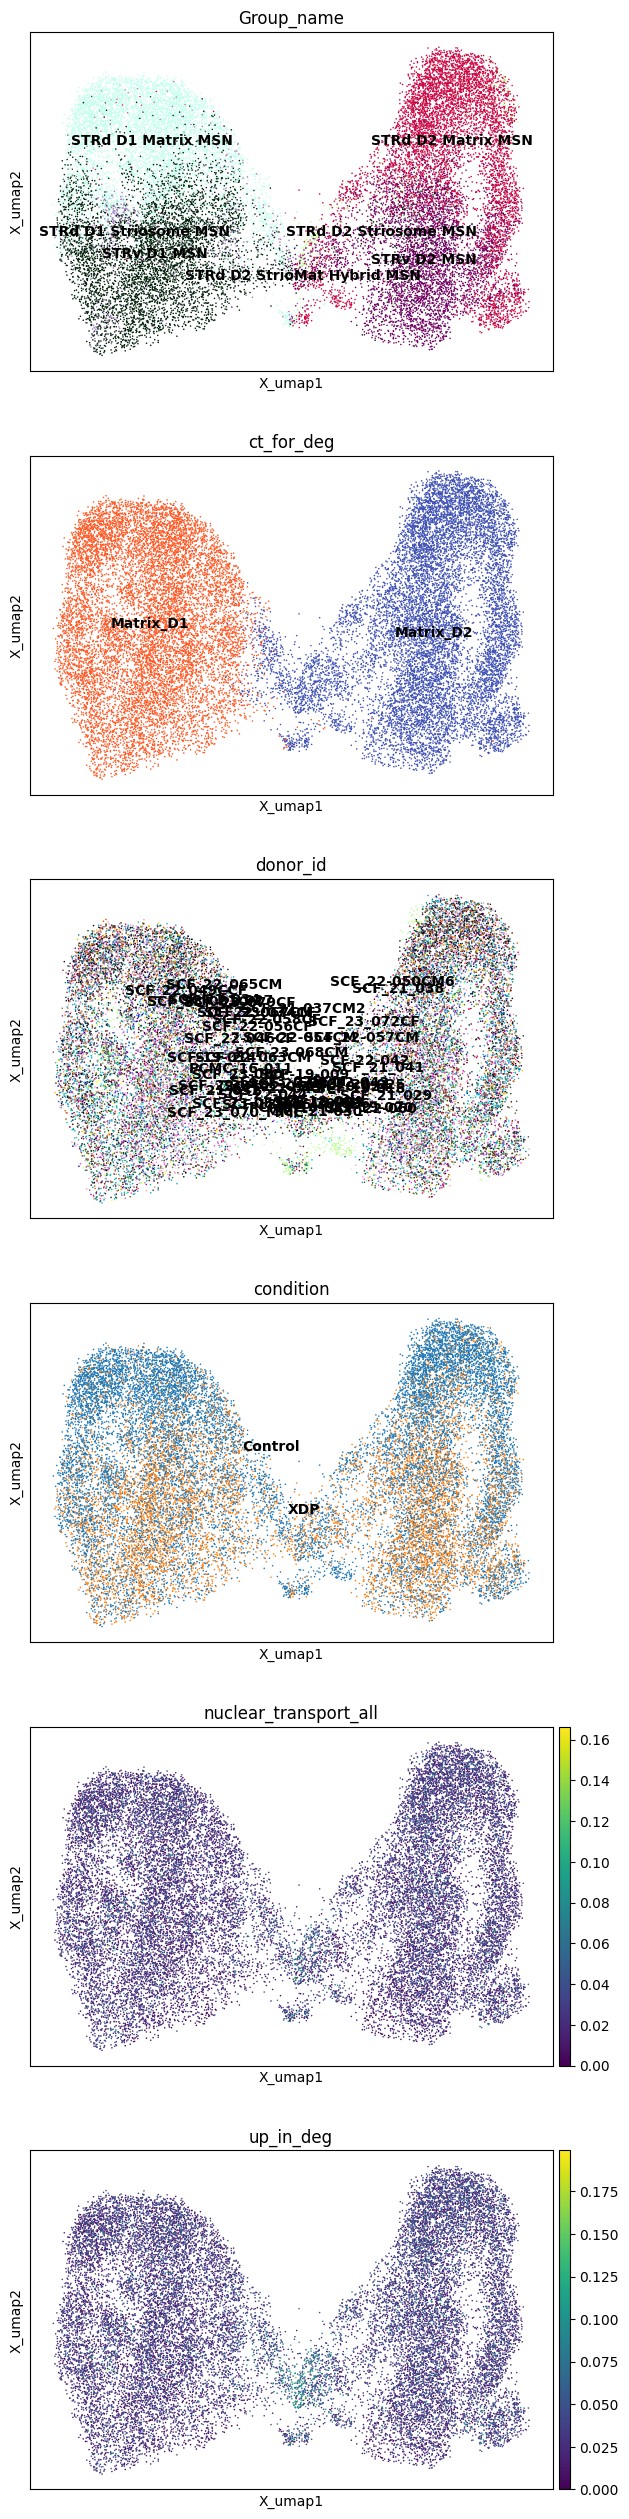

In [6]:
sc.pl.embedding(nucseq_matrix, basis="X_umap", 
                color=["Group_name", "ct_for_deg", "donor_id","condition", *nup_genesets.keys()], 
                s=5, legend_loc="on data", ncols=1)

### Compute nuclear socre per sample

/tmp/ipykernel_632725/2222687716.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['donor_id', 'condition'])  # add your covariates


,donor_id,condition,nuclear_transport_all,up_in_deg
1,PCMC-16-011,XDP,0.026654,0.034725
3,PCMC-16-012,XDP,0.035082,0.046945
5,SCF-18-003,XDP,0.020254,0.024634
7,SCF-18-004,XDP,0.017567,0.029652
9,SCF-18-006,XDP,0.022124,0.030688
11,SCF-19-009,XDP,0.024863,0.031463
13,SCF-19-014,XDP,0.018252,0.030923
15,SCF-19-018,XDP,0.020333,0.029030
17,SCF-19-020,XDP,0.020886,0.025684
19,SCF-20-023,XDP,0.024455,0.035278


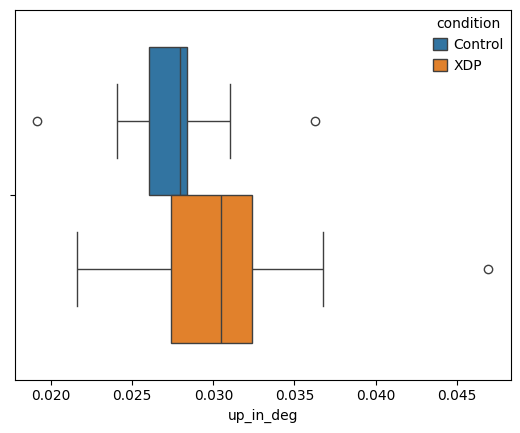

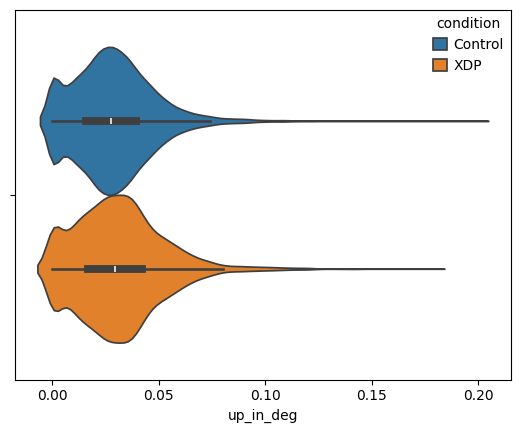

In [12]:
col = "up_in_deg"

pseudobulk = (
    nucseq_matrix.obs
    .groupby(['donor_id', 'condition'])  # add your covariates
    [list(nup_genesets.keys())]                                  # the score columns
    .median()                                                     # median is more robust than mean
    .reset_index()
)
pseudobulk = pseudobulk.dropna(subset=[col])  # drop samples with missing scores
display(pseudobulk)

from scipy.stats import mannwhitneyu
sns.boxplot(data=pseudobulk, x=col, hue="condition"); plt.show()
sns.violinplot(data=nucseq_matrix.obs, x=col, hue="condition"); plt.show()

### Compare sample nuclear score wihr other sample metrics

In [8]:
# add metadata
df_meta = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/XDP dataset metadata - Gabri's Version.csv")
#df_meta['donor_id'] = df_meta['donor_id'].map(normalize_donor_id)
df_meta.rename(columns={'condition': 'condition_from_metadata'}, inplace=True)
df_meta.drop(columns=['from_where_this_info_comes_from'], inplace=True)
df_meta.columns = df_meta.columns.str.lower()


def normalize_donor_id(d):
    import re
    if d == 'unassigned':
        return d
    if d.startswith("PCMC"):
        return d
    if d == "SCF_23_070_MMC":
        return "SCF-23-070"
    d = re.sub(r'(CM2|CM6|CCF|MMC|CM|CF)$', '', d)  # strip suffixes
    d = re.sub(r'^PCMC', 'SCF', d)                    # fix prefix
    d = re.sub(r'[-_]+', '-', d)                       # normalize separators
    return d

pseudobulk['donor_id'] = pseudobulk['donor_id'].map(normalize_donor_id)

df_meta = df_meta.merge(pseudobulk.drop(columns=['condition']), on='donor_id', how='left')

display(df_meta)


,donor_id,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,...,year_collected,repeat_length,repeat_length_notes,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,nuclear_transport_all,up_in_deg
0,SCF-22-054,SCF-22-054CM,M,Control,C_1,6.88,0.79,5.0,A,6.0,...,2022,0,NaN,not_applicable,51,not_applicable,0.0,Acute Myocardial Infarction,0.019556,0.028117
1,SCF-23-075,SCF_23_075CM,M,Control,C_2,6.84,0.80,5.0,A,NaN,...,2023,0,NaN,not_applicable,60,not_applicable,0.0,Uremia,0.028129,0.036246
2,SCF-22-067,SCF_22_067CM,M,Control,C_2,6.08,0.73,5.0,A,NaN,...,2023,0,NaN,not_applicable,19,not_applicable,0.0,Stab wound,0.022098,0.027813
3,SCF-23-079,SCF_23_079CF,F,Control,C_2,5.61,0.74,5.0,A,NaN,...,2023,0,NaN,not_applicable,47,not_applicable,0.0,Colon Carcinoma,0.021966,0.026182
4,SCF-22-065,SCF_22_065CM,M,Control,C_2,5.35,0.71,5.0,A,NaN,...,2022,0,NaN,not_applicable,69,not_applicable,0.0,Heart Failure,0.021439,0.024081
5,SCF-23-072,SCF_23_072CF,F,Control,C_2,5.11,0.72,5.0,A,NaN,...,2023,0,NaN,not_applicable,28,not_applicable,0.0,Sepsis,0.022084,0.026058
6,SCF-22-050,SCF_22-050CM6,M,Control,C_3,6.39,0.74,4.0,B,6.2,...,2022,0,NaN,not_applicable,78,not_applicable,0.0,NaN,0.025469,0.031020
7,SCF-23-068,SCF-23-068CM,M,Control,C_1,6.30,0.76,4.0,B,6.0,...,2023,0,NaN,not_applicable,43,not_applicable,0.0,Myocardial Infraction,0.020912,0.027951
8,SCF-23-074,SCF_23_074CF,F,Control,C_2,4.42,0.66,4.0,B,NaN,...,2023,0,NaN,not_applicable,26,not_applicable,0.0,Uremia,0.020333,0.026735
9,SCF-22-057,SCF_22-057CM,M,Control,C_3,6.76,0.80,3.5,BC,NaN,...,2022,0,NaN,not_applicable,66,not_applicable,0.0,Community Aquire Pnuemonia High Risk,0.022940,0.028255


/tmp/ipykernel_632725/1744587834.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(sub[xvar], sub[score_name])
/tmp/ipykernel_632725/1744587834.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(sub[xvar], sub[score_name])


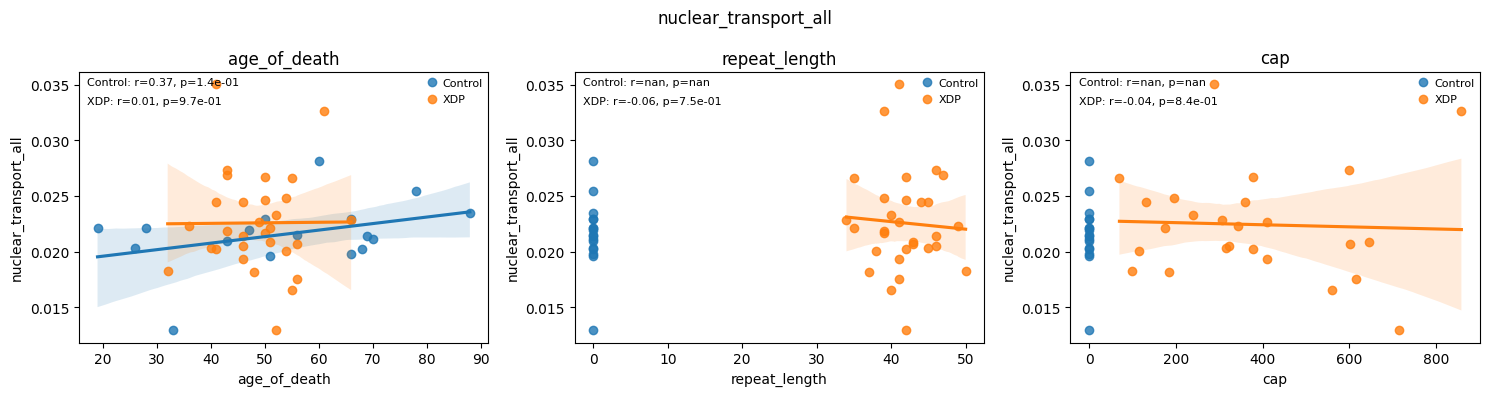

/tmp/ipykernel_632725/1744587834.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(sub[xvar], sub[score_name])
/tmp/ipykernel_632725/1744587834.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(sub[xvar], sub[score_name])


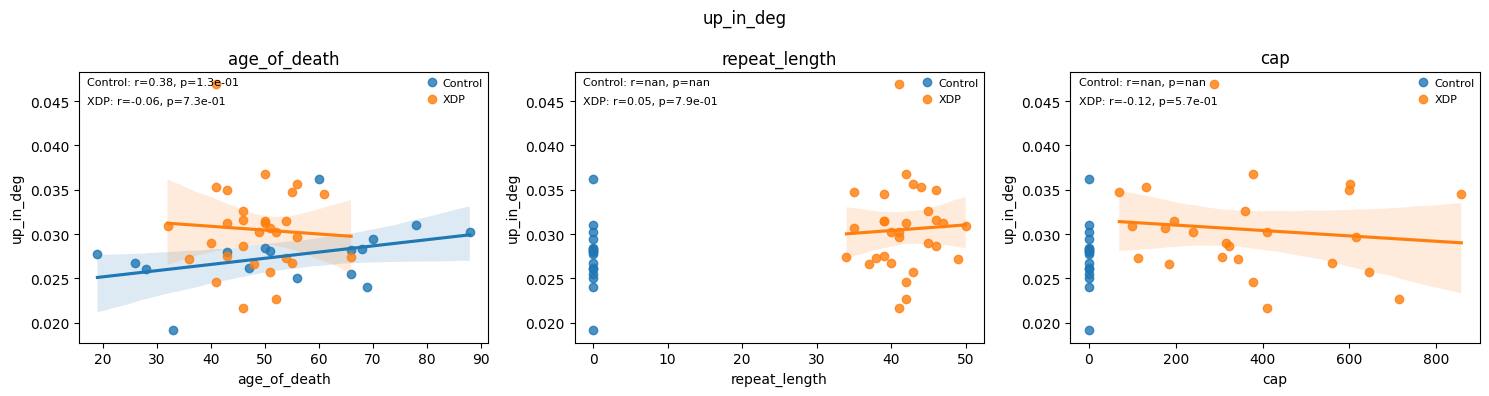

In [11]:
from scipy.stats import pearsonr

xvars = ["age_of_death", "repeat_length", "cap"]

for score_name in nup_genesets:
    fig, axes = plt.subplots(1, len(xvars), figsize=(5*len(xvars), 4))
    for ax, xvar in zip(axes, xvars):
        for i, (cond, sub) in enumerate(df_meta.dropna(subset=[xvar, score_name]).groupby("condition")):
            sns.regplot(data=sub, x=xvar, y=score_name, ax=ax, label=str(cond))
            r, p = pearsonr(sub[xvar], sub[score_name])
            ax.text(0.02, 0.98 - i*0.07, f"{cond}: r={r:.2f}, p={p:.1e}",
                    transform=ax.transAxes, va="top", fontsize=8)
        ax.set_title(xvar)
        ax.legend(fontsize=8)
    fig.suptitle(score_name)
    fig.tight_layout()
    plt.show()

#